In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## import

In [33]:
sim_games_data_df = pd.json_normalize(
    pd.read_json('simulation_results/1cdd591f_macau_simulation.json', lines=True).to_dict(orient='records')
)
sim_games_results_df = pd.read_json('simulation_results/1cdd591f_macau_simulation_results.json', lines=True)

In [34]:
sim_games_data_df.head()

,game_id,move_num,player,hand_size_before,top_card_before,effect_active,cards_in_hand_after,top_card_after,deck_remaining,action_made.action,action_made.card
0,0,1,0,5,10 Spades,False,4,5 Spades,32,play_card,5 Spades
1,0,2,1,5,5 Spades,False,6,5 Spades,31,draw_card,NaN
2,0,3,2,5,5 Spades,False,4,8 Spades,31,play_card,8 Spades
3,0,4,0,4,8 Spades,False,3,Q Clubs,31,skip,Q Clubs
4,0,5,1,6,Q Clubs,False,5,4 Clubs,31,block,4 Clubs


In [36]:
sim_games_results_df.head()

,game_id,winner,total_moves
0,0,Aggressive,23
1,1,Random,28
2,2,Random,247
3,3,Random,41
4,4,Random,43


## total moves mean and std per strategy

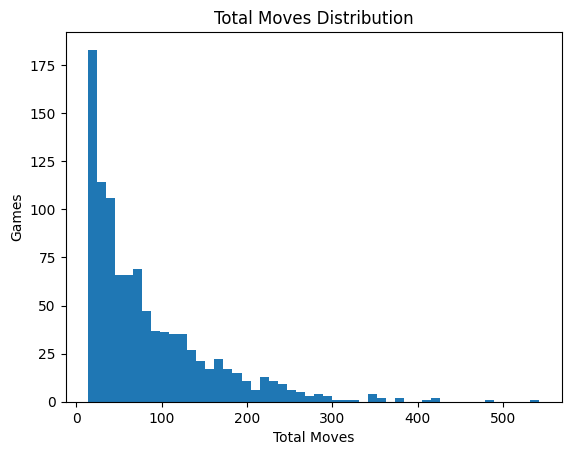

In [60]:
plt.hist(sim_games_results_df["total_moves"], bins=50)
plt.title("Total Moves Distribution")
plt.xlabel("Total Moves")
plt.ylabel("Games")
plt.show()

In [91]:
print(sim_games_results_df.groupby("winner")["total_moves"].quantile([0.25, 0.5, 0.75, 0.9, 0.99]))

winner          
Aggressive  0.25     29.25
            0.50     58.50
            0.75    118.75
            0.90    193.90
            0.99    332.99
Cautious    0.25     33.00
            0.50     66.00
            0.75    121.00
            0.90    192.40
            0.99    349.98
Random      0.25     29.00
            0.50     59.00
            0.75    105.00
            0.90    166.00
            0.99    283.05
Name: total_moves, dtype: float64


In [93]:
sim_games_results_df.groupby("winner").agg(
    total_moves_median=pd.NamedAgg(column="total_moves", aggfunc="median"),
    total_moves_qcd=pd.NamedAgg(column="total_moves", aggfunc=lambda x: (x.quantile(0.75) - x.quantile(0.25)) / (x.quantile(0.75) + x.quantile(0.25))),
)

,total_moves_median,total_moves_qcd
winner,,
Aggressive,58.5,0.604730
Cautious,66.0,0.571429
Random,59.0,0.567164


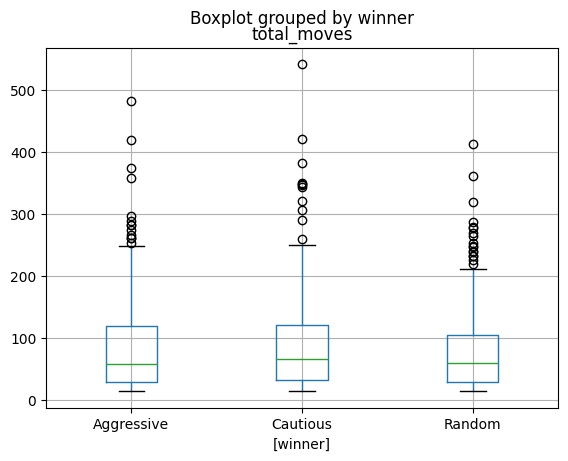

In [85]:
sim_games_results_df[["total_moves", "winner"]].boxplot(by="winner")
plt.show()

## winrate per strategy

In [45]:
sim_group_winners = sim_games_results_df.groupby("winner").agg(
    winrate=pd.NamedAgg(column="game_id", aggfunc=lambda x: x.count() / len(sim_games_results_df)),
)
sim_group_winners

,winrate
winner,
Aggressive,0.342
Cautious,0.302
Random,0.356


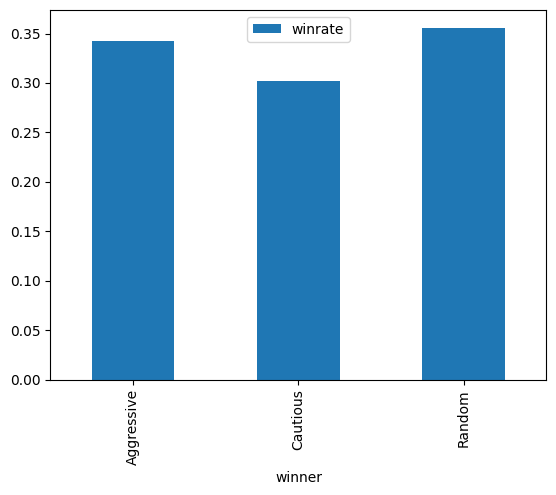

In [47]:
sim_group_winners.plot.bar()

## is

0.25     31.00
0.50     61.00
0.75    117.25
0.90    183.00
0.99    348.02
Name: total_moves, dtype: float64
